In [1]:
import os
import matplotlib.pyplot as plt
import cv2
import shutil
import random

ModuleNotFoundError: No module named 'cv2'

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive',force_remount=True)

In [ ]:
file_name='/content/gdrive/My Drive/weather_data.zip' ## repalce the path with relevent path on your drive
os.mkdir('Data')
from zipfile import ZipFile
with ZipFile(file_name, 'r') as zip_ref:
  zip_ref.extractall('Data')


print('Extract completed!')
!ls


In [ ]:
### collecting image names 
cloudy=os.listdir('Data/cloudy')
rain=os.listdir('Data/rain')
sunrise=os.listdir('Data/sunrise')
sunshine=os.listdir('Data/sunshine')

In [ ]:

plt.figure(figsize = (15,15))
for i in range(4):
    plt.subplot(1, 4, i+1)
    x=random.randint(0,len(cloudy))

    img = cv2.imread('Data/cloudy' + "/" + cloudy[x])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title('Cloudy')
    plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize = (15,15))
for i in range(4):
    plt.subplot(1, 4, i+1)
    x=random.randint(0,len(rain))

    img = cv2.imread('Data/rain' + "/" + rain[x])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title('Rain')
    plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize = (15,15))
for i in range(4):
    plt.subplot(1, 4, i+1)
    x=random.randint(0,len(cloudy))

    img = cv2.imread('Data/sunrise' + "/" + sunrise[x])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title('Sunrise')
    plt.tight_layout()
plt.show()

NameError: name 'random' is not defined

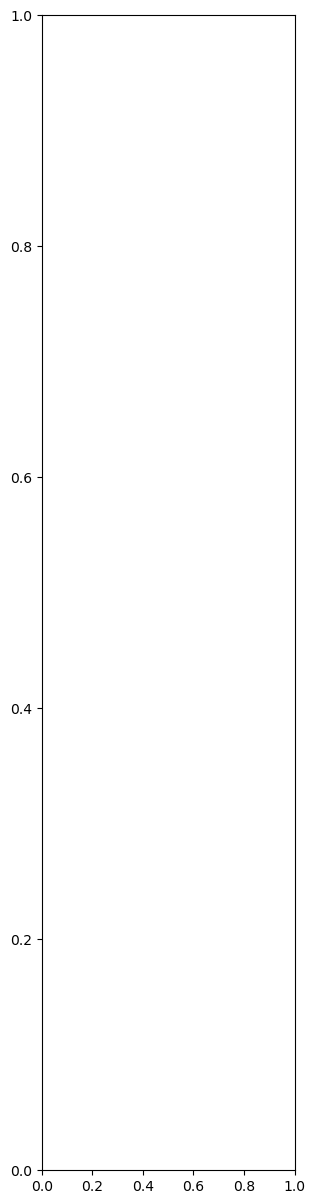

In [2]:
plt.figure(figsize = (15,15))
for i in range(4):
    plt.subplot(1, 4, i+1)
    x=random.randint(0,len(sunshine))

    img = cv2.imread('Data/sunshine' + "/" + sunshine[x])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title('Sunshine')
    plt.tight_layout()

In [3]:
!pip install split-folders

import split_folders
orig_path = '/content/Data/'
output_path = '/content/dataset/'
### split for train :validation:tet == 75:20:05
split_folders.ratio(orig_path, output=output_path, seed=254, ratio=(.75, .20,.05))

  Obtaining dependency information for split-folders from https://files.pythonhosted.org/packages/b6/d5/307d63c03356bad6e141d8718d3f4116f51bd9c4b09e2614ffcee1f3c6fd/split_folders-0.5.1-py3-none-any.whl.metadata


ModuleNotFoundError: No module named 'split_folders'

In [ ]:
total_train = 0
for root, dirs, files in os.walk('/content/dataset/train'):
    total_train += len(files)
print('Train set size: ',total_train)
total_val = 0
for root, dirs, files in os.walk('/content/dataset/val'):
    total_val += len(files)
print('Validation set size: ',total_val)
total_test = 0
for root, dirs, files in os.walk('/content/dataset/test'):
    total_test += len(files)
print('Test set size: ',total_test)

In [ ]:
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dropout, Flatten, Dense, Activation,GlobalAveragePooling2D
from keras import callbacks
from keras.layers.normalization import BatchNormalization
from keras.layers.convolutional import Conv2D, MaxPooling2D
from keras.utils import np_utils
from keras import backend as K 
from keras.initializers import glorot_uniform
from keras.regularizers import l2
import scipy.misc
import matplotlib.pyplot  as plt

In [ ]:
## setting train and validatin path
train_data_path = '/content/dataset/train'
validation_data_path = '/content/dataset/val'

In [ ]:
## Setting Image height and width to 150 each since all images are of varying size 
img_width=150
img_height =150
### CNN architecture parameters
batch_size = 32
samples_per_epoch = 1000
validation_steps = 32
no_filters1 = 32
no_filters2 = 64
no_filters3=128
conv1_size = 3
conv2_size = 3
conv3_size=5
pool_size = 2
## no of classes according to dataset 4 in our case
classes_num = 4
## Defining initial learning rate
lr = 0.001
epochs=200

In [ ]:
train_datagen = ImageDataGenerator(
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        horizontal_flip=True,
        fill_mode="nearest",rescale=1. / 255)
test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = train_datagen.flow_from_directory(
    train_data_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical')

validation_generator = test_datagen.flow_from_directory(
    validation_data_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical')

In [ ]:
model = Sequential()
model.add(Conv2D(filters=no_filters1,kernel_size=(3,3), border_mode ="same",data_format='channels_last', input_shape=(img_width, img_height, 3)))
model.add(BatchNormalization(axis = 3))
model.add(Activation("relu"))
model.add(Conv2D(filters=no_filters1,kernel_size=(3,3), border_mode ="same",data_format='channels_last', input_shape=(img_width, img_height, 3)))
model.add(BatchNormalization(axis = 3))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(pool_size, pool_size),data_format='channels_last'))

model.add(Conv2D(filters=no_filters2,kernel_size=(3,3), border_mode ="same",data_format='channels_last'))
model.add(BatchNormalization(axis = 3))
model.add(Activation("relu"))
model.add(Conv2D(filters=no_filters2,kernel_size=(3,3), border_mode ="same",data_format='channels_last'))
model.add(BatchNormalization(axis = 3))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(pool_size, pool_size),data_format='channels_last'))


model.add(Conv2D(filters=no_filters3,kernel_size=(5,5), border_mode ="same",data_format='channels_last'))
model.add(BatchNormalization(axis = 3))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(pool_size, pool_size),data_format='channels_last'))

model.add(GlobalAveragePooling2D())

model.add(Dense(1024))
model.add(Activation("relu"))
model.add(Dropout(0.5))
model.add(Dense(512))
model.add(Activation("relu"))
model.add(Dropout(0.5))
model.add(Dense(128))
model.add(Activation("relu"))
model.add(Dropout(0.5))
model.add(Dense(4, activation='softmax'))
epochs = 200

### Using adam optimizer 
adam = optimizers.Adam(lr=lr, beta_1=0.9, beta_2=0.999, epsilon=1e-5)
model.compile(loss='categorical_crossentropy',
              optimizer=adam,
            metrics=['accuracy'])

model.summary()

In [ ]:
target_dir = './models'
if not os.path.exists(target_dir):
  os.mkdir(target_dir)

In [ ]:
log_dir = './tf-log/'
tb_cb = callbacks.TensorBoard(log_dir=log_dir, histogram_freq=0)
file_path= "models/best_weight{epoch:03d}.h5"
chkpt=callbacks.ModelCheckpoint(file_path, monitor='val_acc', verbose=0, save_best_only=True, save_weights_only=True, mode='auto')
lr_red=callbacks.ReduceLROnPlateau(monitor = "val_acc", factor = 0.1, patience = 5,
  verbose = 1, mode = "auto", cooldown = 0,
  min_lr = 1e-30)

cbks = [tb_cb,chkpt,lr_red]

In [ ]:
history=model.fit_generator(
    train_generator,
    steps_per_epoch=130,
    epochs=200,
    validation_data=validation_generator,
    callbacks=cbks,
    validation_steps=32)

In [ ]:
model.save('models/weather_model.h5')

In [ ]:
from keras.models import load_model
from keras.preprocessing import image

In [ ]:
model_final=load_model('models/weather_model.h5')
model_final.load_weights('/content/gdrive/My Drive/best_weight037.h5')

In [ ]:
model_final.summary()

In [ ]:
class_dict={ 0:'Cloudy', 1:'Rain', 2:'Sunrise',3 :'Sunshine'}
sunny1=os.listdir('dataset/test/sunshine')
#print(sunny1)
for img in sunny1:
    img_path='dataset/test/sunshine/'+img
    img = image.load_img(img_path, target_size=(150, 150))
    img_tensor = image.img_to_array(img)
    plt.imshow(img_tensor/255)
    plt.show()
    img_tensor = np.expand_dims(img_tensor, axis=0)
         
    img_tensor /= 255. 
    ### predict takes image tensor of (batchsize,heighht,width,channels)  
    ### return an array for all images in batch with probability for each class 
    pred = model_final.predict(img_tensor)
    print('Predicted class probability for image: ',pred)
    ###  Class number with highest probablity (Classification result of CNN)  
    classes = np.argmax(pred) 
    print('Predicted Class :',class_dict[classes])
 

In [ ]:
cloudy=os.listdir('dataset/test/cloudy')
for img in cloudy:
    img_path='./dataset/test/cloudy/'+img
    img = image.load_img(img_path, target_size=(150, 150))
    img_tensor = image.img_to_array(img)
    plt.imshow(img_tensor/255)
    plt.show()
    img_tensor = np.expand_dims(img_tensor, axis=0)
         
    img_tensor /= 255. 
    pred = model_final.predict(img_tensor)
    print('Predicted class probability for imagey: ',pred)
    classes = np.argmax(pred) 
    print('Class :',class_dict[classes])

In [ ]:
sun_rise=os.listdir('dataset/test/sunrise')
for img in sun_rise:
    img_path='./dataset/test/sunrise/'+img
    img = image.load_img(img_path, target_size=(150, 150))
    img_tensor = image.img_to_array(img)
    plt.imshow(img_tensor/255)
    plt.show()
    img_tensor = np.expand_dims(img_tensor, axis=0)
         
    img_tensor /= 255. 
    pred = model_final.predict(img_tensor)
    print('Predicted class probability for image: ',pred)
    classes = np.argmax(pred) 
    print('Classes :',class_dict[classes])

In [ ]:
!pip install lime
import lime 
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [ ]:
img_path='./dataset/test/sunrise/'+sun_rise[7]  ### repalce path with the path for image u want to be expalined
img = image.load_img(img_path, target_size=(150, 150))
img = image.img_to_array(img)/255

plt.imshow(img)
plt.title('Image')
plt.show()

img = np.expand_dims(img, axis=0)

In [ ]:
explainer = lime_image.LimeImageExplainer()

In [ ]:
%%time 
explanation = explainer.explain_instance(img, model_final.predict, top_labels=4
                                         , hide_color=0, num_samples=1000)

In [ ]:
print('Class Order')
labels=[print(no+1,class_dict[label]) for no,label in enumerate(explanation.top_labels)]

print('For current image instance CNN model has classified Image as: ',class_dict[explanation.top_labels[0]])

In [ ]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=4, hide_rest=True)
plt.imshow(mark_boundaries(temp,mask))

In [ ]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=4, hide_rest=False)
plt.imshow(mark_boundaries(temp,mask))